Consider a scenario where we want to predict the price of house given we have the following inputs: <br>
    1. Living Area <br>
    2. # Bedrooms <br>
### Notations:
$x_i$ - Input features where $x_1$ - living area, and $x_2$ - # Bedrooms <br>
$y $ - Target Variable; $ y$ - Price of the house <br>

Our goal is learn a function called hypothesis, that maps our input x to our output y, For Linear Regression, we assume the relationship is a straight line <br>
##### $h_{\theta}(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2$

The $\theta$'s are called parameters (also weights). $\theta_0$ is the intercept term, and rest of the parameters determine the slope <br>
We can simply write the above equation as (in vector form)
##### $h_{\theta}(x) = \sum_{i=0}^d \theta_i x_i = \theta^T x$
where $x_0$ = 1 and d is the no of features. <br>
The code for visualizing this is below:



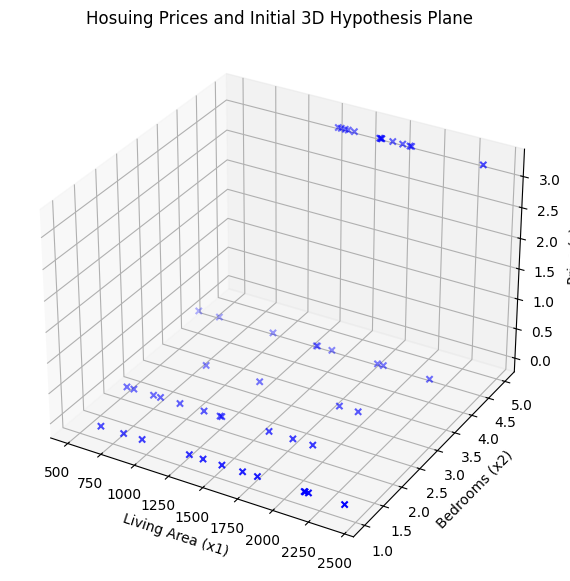

In [7]:
#NOT COMPULSORY - THIS IS GENERATED DATA - THERE IS AN ANOTHER EXAMPLE BELOW WITH REAL DATA

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_samples = 50
X1 = 2000 * np.random.rand(n_samples) + 500 #Living area: 500 to 2500 Sqft
X2 = np.random.randint(1, 6, n_samples) # Bedrooms 1 to 5

y = 50 + 0.15 * X1 + 20 ** X2 + np.random.randn(n_samples) * 20 #Real underlying relationship with some noise

#choose random parameters
theta_0 = 0.0
theta_1 = 0.05
theta_2 = 10.0

#create a meshgrid to plot the hypothesis plane
x1_range = np.linspace(500, 2500, 10)
x2_range = np.linspace(1, 5, 10)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
y_plane = theta_0 + theta_1 * X1_mesh + theta_2 * X2_mesh

#plot the 3D data and the initial hypothesis plane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

#plot actual data points 
ax.scatter(X1, X2, y, color = 'blue', marker = 'x', label = 'Training Data')

ax.set_xlabel('Living Area (x1)')
ax.set_ylabel('Bedrooms (x2)')
ax.set_zlabel('Price (y)')
ax.set_title('Hosuing Prices and Initial 3D Hypothesis Plane')
plt.show()

In [ ]:
print("California Housing Dataset Information:")
print(f"Shape: {X_full.shape}")
print(f"Number of samples: {X_full.shape[0]}")
print(f"Number of features: {X_full.shape[1]}")
print(f"\nFeature names:")
for i, name in enumerate(california.feature_names):
    print(f"  {i}: {name}")
print(f"\nTarget variable: {california.target_names[0]}")
print(f"Target shape: {y_full.shape}")
print(f"\nData types:")
print(f"  Features (X_full): {X_full.dtype}")
print(f"  Target (y_full): {y_full.dtype}")
print(f"\nTarget value range: [{y_full.min():.3f}, {y_full.max():.3f}]")
print(f"Target description: Median house values in $100,000s")

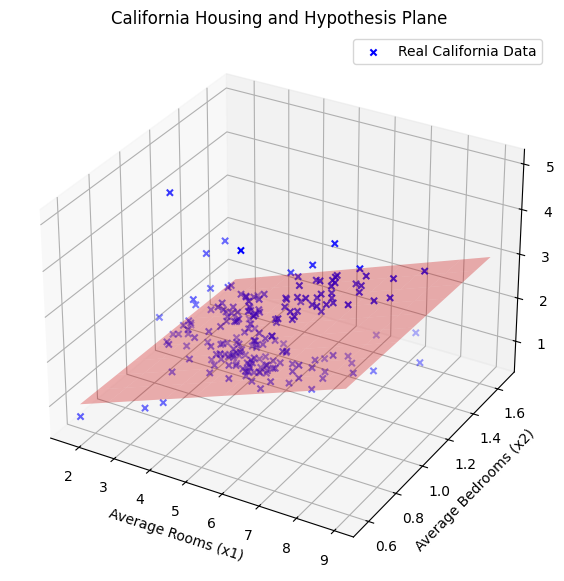

In [8]:
#Let's take an example of real data where x1 is average no of rooms and x2 is average no of bedrooms
from sklearn.datasets import fetch_california_housing

# 1. Fetch the real California Housing dataset
california = fetch_california_housing()
X_full = california.data
y_full = california.target # Prices in $100,000s

# Extract AveRooms (index 2) and AveBedrms (index 3)
X1_full = X_full[:, 2]
X2_full = X_full[:, 3]

# 2. Filter out extreme outliers for better visualization and sample 200 points
mask = (X1_full < 10) & (X2_full < 3)
X1 = X1_full[mask][:200]
X2 = X2_full[mask][:200]
y = y_full[mask][:200]

# 3. Pick random parameters for our initial hypothesis plane
theta_0 = 0.5   # Base price in $100k
theta_1 = 0.3   # Price per average room
theta_2 = -0.1  # Price per average bedroom

# 4. Create a meshgrid to plot the hypothesis plane
x1_range = np.linspace(X1.min(), X1.max(), 10)
x2_range = np.linspace(X2.min(), X2.max(), 10)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
y_plane = theta_0 + theta_1 * X1_mesh + theta_2 * X2_mesh

# 5. Plot the 3D data and the initial hypothesis plane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, y, color='blue', marker='x', label='Real California Data')
ax.plot_surface(X1_mesh, X2_mesh, y_plane, color='red', alpha=0.3)

ax.set_xlabel('Average Rooms (x1)')
ax.set_ylabel('Average Bedrooms (x2)')
ax.set_zlabel('Price in $100k (y)')
ax.set_title('California Housing and Hypothesis Plane')
plt.legend()
plt.show()


## The Cost Function

Now that we have our plane, we need a mathematical way to measure how bad our current plane is. <br>
We define a function that measures how close our predictions $h_{\theta}(x^{(i)})$ are to the actual prices $y^{(i)}$. <br>
<br>
We define Cost Function $J(\theta)$ as

##### $ J(\theta) = \frac{1}{2} \sum_{i=1}^n (h_\theta(x^{(i)}) - y^{(i)})^2$

1. The inner error: $h_\theta(x^{(i)}) - y^{(i)}$ calculates the vertical distance between our plane's prediction point and actual data point for a single house. <br>
2. The Summation: $\sum_{i = 1}^n$ iterates through all of our n examples in the training set and adds their errors together. <br>
3. We square the inner error to remove the negative values and also because it punishes large errors a lot <br>
4. The fraction 1/2 will make the calculation easier in the next step. <br>
This specific formulation is called the least square cost function. <br>

## Gradient Descent (The LMS Algorithm)
We need to make a search algorithm that starts with our initial guess for $\theta$ and repeatedly change to make $J(\theta)$ smaller, hopefully converging it to the minimum. <br>

To do this, we will use the Gradient Descent Algorithm. The idea is to calculate the slope (the gradeint) of our cost function at our current position and take a step down.<br>
We will look at one single training example to keep it clean. We need to find the partial derivative of J($\theta$) with respect to specific parameter $\theta_j$ <br>
##### $\frac{\partial}{\partial \theta_j} J(\theta) = \frac{\partial}{\partial \theta_j} \frac{1}{2} (h_{\theta}(x) - y)^2$ 
##### $2.\frac{1}{2}(h_{\theta}(x) - y) \frac{\partial}{\partial \theta_j} \frac{1}{2} (h_{\theta}(x) - y) $
Substitute $h_{\theta}(x) = \sum_{i = 0}^n\theta_i x_i$
then you would get <br>
##### $(h_\theta(x) - y) \cdot \frac{\partial}{\partial \theta_j} \left( \sum_{i=0}^d \theta_i x_i - y \right)$
##### $ (h_\theta(x) - y) x_j$

To get a step down from the slope, we subtract this gradient from our current parameter. Here $\alpha$ is the learning rate, which controls our how big our step is gonna be
##### $\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} $
Plug in our derivate and you get
##### $\theta_j := \theta_j + \alpha (y - h_{\theta}(x))x_j$

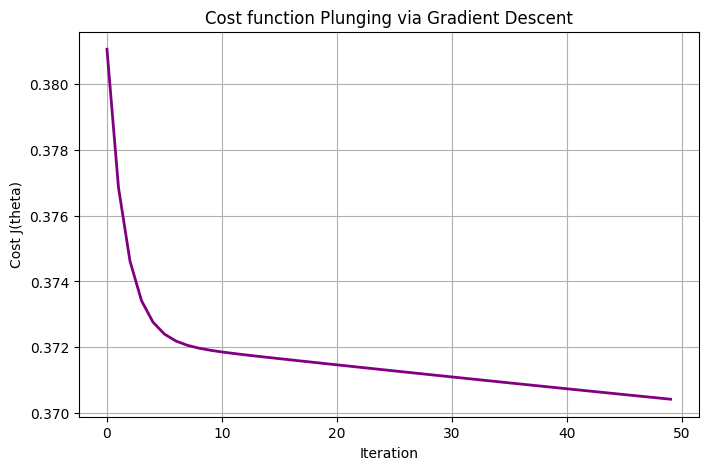

Optimized parameters: theta_0=0.499, theta_1=0.332, theta_2=-0.124


In [11]:
#Applying this to our database of n houses, we just sum up the gradients for all the examples before taking a step. This is called Batch Gradient Descent.
california = fetch_california_housing()
X_full = california.data
Y_full = california.target

mask = (X_full[:, 2] < 10) & (X_full[:,3] < 3) #making X store 2nd and 3rd columns of the data only if the 2nd column has a number less than 10 and if the the 3rd has a number less than 3
X1 = X_full[mask, 2][:200] 
X2 = X_full[mask, 3][:200]
y = y_full[mask][:200]

n = len(y) #no of examples to train

#Adding x_0 = 1 to our feature matrix so we can use vector dot products
X0 = np.ones(n)
X_matrix = np.column_stack((X0, X1, X2))

# 3. Initialize parameters and hyperparameters
theta = np.array([0.5, 0.3, -0.1])
alpha = 0.01 #Learning rate
iterations = 50

cost_history = []

for i in range(iterations):
    predictions = X_matrix.dot(theta)
    errors = predictions - y

    cost = (1 / (2 * n)) * np.sum(errors ** 2)
    cost_history.append(cost)

    #calculates the gradients for all parameters simultaneously
    gradients = (1/n) * X_matrix.T.dot(errors)

    #Update the parameters
    theta = theta - alpha * gradients

#Plotting the cost dropping over time
plt.figure(figsize=(8,5))
plt.plot(range(iterations), cost_history, color = 'purple', linewidth = 2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title("Cost function Plunging via Gradient Descent")
plt.grid(True)
plt.show()

print(f"Optimized parameters: theta_0={theta[0]:.3f}, theta_1={theta[1]:.3f}, theta_2={theta[2]:.3f}")

In [ ]:
california = fetch_california_housing()
X_full = california.data
y_full = california.target

mask = (X_full[:, 2] < 10) & (X_full[:, 3] < 3)
X1 = X_full[mask, 2][:200]
X2 = X_full[mask, 3][:200]
y = y_full[mask][:200]
n = len(y)

X0 = np.ones(n)
X_matrix = np.column_stack((X0, X1, X2))

theta = np.array([0.5, 0.3])

### The Normal Equations (The Closed - Form Solution)

Gradient Descent is fantastic, but iterating through loops takes time. Since our cost function is a perfect convex bowl, we can actually use calculus and linear algebra to jump straight to the exact bottom of the bowl in a single step, without resorting to an iterative algorithm.

In order to do this efficiently, we write our entire dataset and cost function using matrices and vectors.

Let X be our design matrix. It is an n-by-(d + 1) matrix containing all our training example, where each row is a house

##### $X = \begin{bmatrix} -(x^{(1)})^T- \\ -(x^{(2)})^T- \\ \vdots \\ -(x^{(n)})^T- \end{bmatrix}$

Let y be the n-dimensional vector containing all the target prices
##### $ y = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)}\end{bmatrix} $
We can calculate the predictions for every single house at once by multiplying X $\theta$ <br>
Now our least-squares cost function J($\theta$) can be written in vector form as
##### $J(\theta) = \frac{1}{2}(X\theta - y)^T(X\theta - y)$